<a href="https://colab.research.google.com/github/BALJITrs7/GNN-IDS/blob/main/HostFlow_WithoutTempEdges_Gatv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
!pip install torch-geometric -q

In [69]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data

In [70]:
DATASET_DIR = "/Users/balji/OneDrive/GNN_IDS/Balanced_6Class_400K"

files = {
    "BENIGN.csv":0,
    "DDoS.csv":1,
    "DoS.csv":1,
    "Mirai.csv":1,
    "Recon.csv":1,
    "Spoofing.csv":1
}

dfs = []

for file,label in files.items():

    path = os.path.join(DATASET_DIR,file)

    df = pd.read_csv(path)

    attack_name = file.replace(".csv","")

    df["attack_type"] = attack_name

    df["label"] = label

    dfs.append(df)

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

print(data["attack_type"].value_counts())

(400000, 88)
attack_type
BENIGN      200000
DDoS         40000
DoS          40000
Mirai        40000
Recon        40000
Spoofing     40000
Name: count, dtype: int64


In [71]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(400000, 89)


In [72]:
attack_type_backup = data["attack_type"].copy()

In [73]:
DROP_COLS = [

    "id",
    "expiration_id",

    "src_ip",
    "dst_ip",


   # "dst_port",
    #"src_port",
    #"protocol",
   # "ip_version"

    "src_mac",
    "dst_mac",

    "src_oui",
    "dst_oui",

    "requested_server_name",

    "client_fingerprint",
    "server_fingerprint",

    "user_agent",
    "content_type",

    "application_name",
    "application_category_name",

    "flow_id",
    "label",
    "attack_type",

    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",

    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",

    "dst2src_first_seen_ms",
    "dst2src_last_seen_ms",

    "application_confidence",
    "application_is_guessed",

    "vlan_id",
    "tunnel_id",

    "bidirectional_urg_packets",
    "src2dst_urg_packets",
    "dst2src_urg_packets",

    "dst2src_cwr_packets",
    "dst2src_ece_packets",

    "src_port",

    "bidirectional_duration_ms",
    "bidirectional_packets",

    "src2dst_packets",
    "dst2src_packets",

    "dst2src_min_ps",
    "dst2src_mean_ps",

    "bidirectional_min_piat_ms",
    "bidirectional_stddev_piat_ms",

    "dst2src_min_piat_ms",
    "dst2src_mean_piat_ms",
    "dst2src_max_piat_ms",

    "bidirectional_ece_packets",
    "bidirectional_psh_packets",
    "bidirectional_fin_packets",

    "src2dst_syn_packets",
    "src2dst_cwr_packets",
    "src2dst_ack_packets",
    "src2dst_rst_packets",
    "src2dst_fin_packets",

    "src2dst_mean_piat_ms",
    "src2dst_stddev_ps",

    "dst2src_ack_packets",
    "dst2src_psh_packets",
    "dst2src_rst_packets",
    "dst2src_fin_packets",

]

feature_cols = [

    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:",len(feature_cols))

Features: 30


In [74]:
feature_cols = [
    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:", len(feature_cols))

print("\nRetained Features:\n")
for i, f in enumerate(feature_cols, start=1):
    print(f"{i:2d}. {f}")

Features: 30

Retained Features:

 1. dst_port
 2. protocol
 3. ip_version
 4. bidirectional_bytes
 5. src2dst_duration_ms
 6. src2dst_bytes
 7. dst2src_duration_ms
 8. dst2src_bytes
 9. bidirectional_min_ps
10. bidirectional_mean_ps
11. bidirectional_stddev_ps
12. bidirectional_max_ps
13. src2dst_min_ps
14. src2dst_mean_ps
15. src2dst_max_ps
16. dst2src_stddev_ps
17. dst2src_max_ps
18. bidirectional_mean_piat_ms
19. bidirectional_max_piat_ms
20. src2dst_min_piat_ms
21. src2dst_stddev_piat_ms
22. src2dst_max_piat_ms
23. dst2src_stddev_piat_ms
24. bidirectional_syn_packets
25. bidirectional_cwr_packets
26. bidirectional_ack_packets
27. bidirectional_rst_packets
28. src2dst_ece_packets
29. src2dst_psh_packets
30. dst2src_syn_packets


In [75]:
top30 = {
    "bidirectional_mean_ps",
    "dst2src_syn_packets",
    "src2dst_min_ps",
    "ip_version",
    "src2dst_max_piat_ms",
    "dst2src_stddev_piat_ms",
    "bidirectional_max_piat_ms",
    "bidirectional_rst_packets",
    "src2dst_max_ps",
    "src2dst_duration_ms",
    "src2dst_bytes",
    "src2dst_ece_packets",
    "bidirectional_max_ps",
    "dst2src_bytes",
    "bidirectional_bytes",
    "dst2src_max_ps",
    "bidirectional_min_ps",
    "bidirectional_syn_packets",
    "dst2src_stddev_ps",
    "bidirectional_ack_packets",
    "protocol",
    "dst_port",
    "bidirectional_mean_piat_ms",
    "dst2src_duration_ms",
    "src2dst_mean_ps",
    "src2dst_min_piat_ms",
    "bidirectional_stddev_ps",
    "src2dst_stddev_piat_ms",
    "bidirectional_cwr_packets",
    "src2dst_psh_packets"
}

retained = set(feature_cols)

print("Missing from retained:")
print(sorted(top30 - retained))

print("\nExtra retained features:")
print(sorted(retained - top30))

Missing from retained:
[]

Extra retained features:
[]


In [76]:
for col in feature_cols:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[feature_cols] = (
    data[feature_cols]
    .fillna(0)
)

In [77]:
scaler = StandardScaler()

X = scaler.fit_transform(
    data[feature_cols]
)

print(X.shape)


(400000, 30)


In [78]:
all_hosts = pd.concat(
    [
        data["src_ip"],
        data["dst_ip"]
    ]
).unique()

host_to_id = {

    host : idx + len(data)

    for idx,host
    in enumerate(all_hosts)
}

num_flow_nodes = len(data)

num_host_nodes = len(all_hosts)

print("Flow Nodes:",num_flow_nodes)
print("Host Nodes:",num_host_nodes)

Flow Nodes: 400000
Host Nodes: 4572


In [79]:
edges = []

for flow_id,row in data.iterrows():

    src_host = host_to_id[
        row["src_ip"]
    ]

    dst_host = host_to_id[
        row["dst_ip"]
    ]

    edges.append(
        [flow_id,src_host]
    )

    edges.append(
        [src_host,flow_id]
    )

    edges.append(
        [flow_id,dst_host]
    )

    edges.append(
        [dst_host,flow_id]
    )

print("Host-flow edges built")

Host-flow edges built


In [ ]:
edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

In [80]:
src_groups = data.groupby(
    "src_ip"
)["flow_id"].apply(list)

print(
    "Groups:",
    len(src_groups)
)

Groups: 1303


In [82]:
edge_index = torch.tensor(edges,dtype=torch.long).t().contiguous()
print(edge_index.shape)



torch.Size([2, 3988190])


In [83]:
flow_features = torch.tensor(
    X,
    dtype=torch.float
)

In [84]:
host_features = torch.zeros(

    (
        num_host_nodes,
        flow_features.shape[1]
    ),

    dtype=torch.float
)

host_counts = np.zeros(
    num_host_nodes
)

for flow_id,row in data.iterrows():

    src_idx = (
        host_to_id[
            row["src_ip"]
        ]
        -
        num_flow_nodes
    )

    dst_idx = (
        host_to_id[
            row["dst_ip"]
        ]
        -
        num_flow_nodes
    )

    host_features[src_idx] += flow_features[flow_id]
    host_features[dst_idx] += flow_features[flow_id]

    host_counts[src_idx] += 1
    host_counts[dst_idx] += 1

for i in range(num_host_nodes):

    if host_counts[i] > 0:

        host_features[i] /= (
            host_counts[i]
        )

In [85]:
x = torch.cat(
    [
        flow_features,
        host_features
    ],
    dim=0
)

print(x.shape)

torch.Size([404572, 30])


In [86]:
flow_labels = torch.tensor(
    data["label"].values,
    dtype=torch.long
)

host_labels = torch.full(
    (
        num_host_nodes,
    ),
    -1,
    dtype=torch.long
)

y = torch.cat(
    [
        flow_labels,
        host_labels
    ]
)

print(y.shape)

torch.Size([404572])


In [87]:
flow_hosts = (
    data["src_ip"].astype(str)
    + "_"
    + data["dst_ip"].astype(str)
)

unique_pairs = flow_hosts.unique()

train_pairs, test_pairs = train_test_split(
    unique_pairs,
    test_size=0.2,
    random_state=42
)

train_idx = data[
    flow_hosts.isin(train_pairs)
].index.values

test_idx = data[
    flow_hosts.isin(test_pairs)
].index.values

print("Train flows:", len(train_idx))
print("Test flows :", len(test_idx))

print("Train pairs:", len(train_pairs))
print("Test pairs :", len(test_pairs))

Train flows: 313332
Test flows : 86668
Train pairs: 9756
Test pairs : 2439


In [88]:
total_nodes = (
    num_flow_nodes
    +
    num_host_nodes
)

train_mask = torch.zeros(
    total_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    total_nodes,
    dtype=torch.bool
)

train_mask[
    train_idx
] = True

test_mask[
    test_idx
] = True

print("Train mask:", train_mask.sum().item())
print("Test mask :", test_mask.sum().item())

Train mask: 313332
Test mask : 86668


C:\Users\balji\AppData\Local\Temp\ipykernel_25236\2963144937.py:17: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_mask[


In [89]:

#scaler = StandardScaler()


#scaler.fit(data.loc[train_idx, feature_cols])


#X = scaler.transform(data[feature_cols])


#flow_features = torch.tensor(X, dtype=torch.float)

In [90]:
graph = Data(

    x=x,

    edge_index=edge_index,

    y=y,

    train_mask=train_mask,

    test_mask=test_mask
)

print(graph)

print(
    "Nodes:",
    graph.num_nodes
)

print(
    "Edges:",
    graph.num_edges
)

Data(x=[404572, 30], edge_index=[2, 3988190], y=[404572], train_mask=[404572], test_mask=[404572])
Nodes: 404572
Edges: 3988190


In [91]:
from torch_geometric.loader import NeighborLoader

print("Initializing Mini-Batch Loaders for GPU...")

# We use the [25, 15] neighbor limit and 2048 batch size that previously
# balanced well on your architecture.
train_loader = NeighborLoader(
    graph,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=graph.train_mask,
    shuffle=True,
    num_workers=0
)

test_loader = NeighborLoader(
    graph,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=graph.test_mask,
    shuffle=False,
    num_workers=0
)
print(f"Train subgraphs: {len(train_loader)} | Test subgraphs: {len(test_loader)}")

Initializing Mini-Batch Loaders for GPU...
Train subgraphs: 153 | Test subgraphs: 43


In [92]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class GATModel(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes,
        heads=4
    ):
        super().__init__()

        # Layer 1
        self.conv1 = GATv2Conv(
            in_channels,
            hidden_channels // heads,
            heads=heads
        )

        # Layer 2
        self.conv2 = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads
        )

        # Layer 3: Output matches hidden_channels // 2 (128)
        self.conv3 = GATv2Conv(
            hidden_channels,
            (hidden_channels // 2) // heads,
            heads=heads
        )

        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn3 = torch.nn.BatchNorm1d(hidden_channels // 2)

        self.classifier = torch.nn.Linear(
            hidden_channels // 2,
            num_classes
        )

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.classifier(x)

        return x

In [93]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [94]:
model = GATModel(
    in_channels=graph.num_node_features,
    hidden_channels=256,
    num_classes=2,
    heads=4
)

model = model.to(device)
graph = graph.to(device)

print(model)

GATModel(
  (conv1): GATv2Conv(30, 64, heads=4)
  (conv2): GATv2Conv(256, 64, heads=4)
  (conv3): GATv2Conv(256, 32, heads=4)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)


In [95]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.002,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)

In [96]:
weights = torch.tensor(
    [1.0, 2.0],
    dtype=torch.float
).to(device)

criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [97]:
def train_epoch():
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass on the subgraph
        out = model(batch.x, batch.edge_index)

        # SLICE: Calculate loss strictly for the seed nodes
        loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.batch_size

    return total_loss / graph.train_mask.sum().item()

@torch.no_grad()
def evaluate_epoch(loader, mask_size):
    model.eval()
    correct = 0

    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # Evaluate strictly for the seed nodes
        pred = out[:batch.batch_size].argmax(dim=1)
        y_true = batch.y[:batch.batch_size]

        correct += (pred == y_true).sum().item()

    return correct / mask_size



In [98]:
# Training Execution
for epoch in range(1, 51):
    loss = train_epoch()
    train_acc = evaluate_epoch(train_loader, graph.train_mask.sum().item())
    test_acc = evaluate_epoch(test_loader, graph.test_mask.sum().item())

    scheduler.step()

    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 01 | Loss: 0.2122 | Train Acc: 0.9489 | Test Acc: 0.9291
Epoch 02 | Loss: 0.1235 | Train Acc: 0.9633 | Test Acc: 0.9331
Epoch 03 | Loss: 0.0943 | Train Acc: 0.9742 | Test Acc: 0.9554
Epoch 04 | Loss: 0.0833 | Train Acc: 0.9720 | Test Acc: 0.9569
Epoch 05 | Loss: 0.0755 | Train Acc: 0.9765 | Test Acc: 0.9614
Epoch 06 | Loss: 0.0677 | Train Acc: 0.9809 | Test Acc: 0.9684
Epoch 07 | Loss: 0.0663 | Train Acc: 0.9825 | Test Acc: 0.9696
Epoch 08 | Loss: 0.0601 | Train Acc: 0.9812 | Test Acc: 0.9640
Epoch 09 | Loss: 0.0574 | Train Acc: 0.9829 | Test Acc: 0.9706
Epoch 10 | Loss: 0.0493 | Train Acc: 0.9867 | Test Acc: 0.9725
Epoch 11 | Loss: 0.0540 | Train Acc: 0.9872 | Test Acc: 0.9715
Epoch 12 | Loss: 0.0437 | Train Acc: 0.9878 | Test Acc: 0.9750
Epoch 13 | Loss: 0.0419 | Train Acc: 0.9881 | Test Acc: 0.9735
Epoch 14 | Loss: 0.0387 | Train Acc: 0.9872 | Test Acc: 0.9721
Epoch 15 | Loss: 0.0373 | Train Acc: 0.9900 | Test Acc: 0.9759
Epoch 16 | Loss: 0.0391 | Train Acc: 0.9874 | Test Acc:

In [121]:
model.eval()
all_preds = []

print("Gathering blind test set predictions via subgraphs...")

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # Apply Softmax strictly to the seed nodes
        probs = torch.softmax(out[:batch.batch_size], dim=1)
        attack_prob = probs[:, 1]

        # Maintain your adjusted 0.35 threshold logic
        batch_pred = (attack_prob > 0.35).long()
        all_preds.extend(batch_pred.cpu().numpy())

# Convert the final list back to a tensor so Cell 29 runs seamlessly
pred = torch.tensor(all_preds)
print("Predictions successfully gathered!")

Gathering blind test set predictions via subgraphs...
Predictions successfully gathered!


In [122]:
from sklearn.metrics import (
    classification_report
)

y_true = graph.y[graph.test_mask].cpu().numpy()
y_pred = pred.cpu().numpy()

test_rows = data.iloc[test_idx].reset_index(drop=True)

test_rows["pred"] = y_pred

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     54481
           1       0.97      0.99      0.98     32187

    accuracy                           0.98     86668
   macro avg       0.98      0.98      0.98     86668
weighted avg       0.98      0.98      0.98     86668



In [123]:
test_attack_types = attack_type_backup.iloc[test_idx].reset_index(drop=True)

import pandas as pd

results = []

for attack in [
    "DDoS",
    "DoS",
    "Mirai",
    "Recon",
    "Spoofing"
]:

    mask = (test_attack_types == attack)

    total = mask.sum()

    detected = (
        pd.Series(y_pred)[mask]
        .eq(1)
        .sum()
    )

    recall = detected / total

    results.append([
        attack,
        total,
        detected,
        recall
    ])

recall_df = pd.DataFrame(
    results,
    columns=[
        "Attack",
        "Total",
        "Detected",
        "Recall"
    ]
)

print(recall_df)

     Attack  Total  Detected    Recall
0      DDoS   7058      7024  0.995183
1       DoS    774       766  0.989664
2     Mirai   6568      6556  0.998173
3     Recon  11355     10939  0.963364
4  Spoofing   6432      6426  0.999067


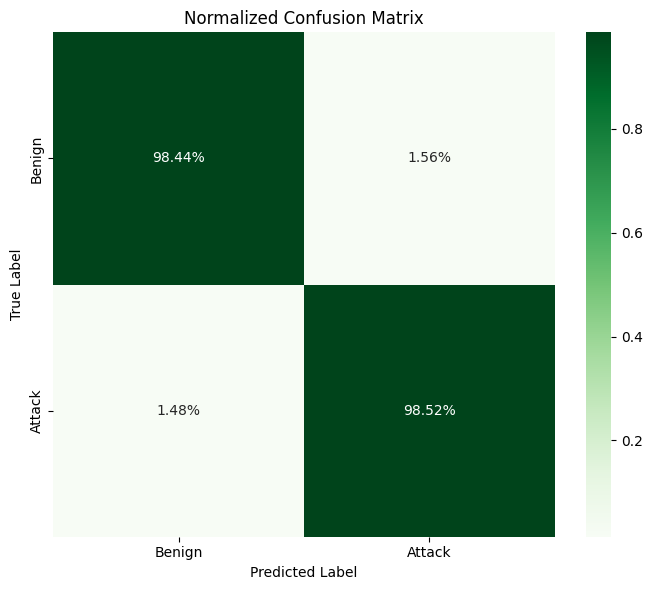

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
#y_true = graph.y[graph.test_mask].cpu().numpy()

# Predicted labels
#y_pred = pred[graph.test_mask].cpu().numpy()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize row-wise
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

In [116]:
recon_rows = test_rows[
    test_rows["attack_type"] == "Recon"
]

recon_rows["pred"] = pd.Series(y_pred)

print(
    recon_rows["pred"]
    .value_counts()
)

pred
1    10906
0      449
Name: count, dtype: int64


In [104]:
recon_fn = recon_rows[
    recon_rows["pred"] == 0
]

print(recon_fn.head())

         id  expiration_id           src_ip            src_mac   src_oui  \
3586   1837              0   18.207.149.112  3c:18:a0:41:c3:a0  3c:18:a0   
4242  12554              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   
4326  17166              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   
4335  17405              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   
4770  25397              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   

      src_port           dst_ip            dst_mac   dst_oui  dst_port  ...  \
3586      3478   192.168.137.66  30:23:03:f3:57:cb  30:23:03     45123  ...   
4242     59003  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   
4326     60763  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   
4335     49900  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   
4770     49281  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   

      application_confidence  requested_server_name  client_fingerpr

In [105]:
recon_fn = recon_rows[
    recon_rows["pred"] == 0
]

print(
    recon_fn["src_ip"]
    .value_counts()
    .head(20)
)

src_ip
192.168.137.41               328
192.168.137.133              104
195.88.50.100                  5
18.207.149.112                 3
172.217.165.10                 2
192.168.137.187                2
192.168.137.103                2
fe80::2a6d:97ff:fe9e:f4d5      1
13.225.195.99                  1
52.216.35.137                  1
Name: count, dtype: int64


In [106]:
print(
    recon_rows["src_ip"]
    .nunique()
)

print(
    recon_fn["src_ip"]
    .nunique()
)

136
10


In [107]:
host = "192.168.137.41"

host_recon = recon_rows[
    recon_rows["src_ip"] == host
]

print(len(host_recon))

print(
    host_recon["pred"]
    .value_counts()
)

1557
pred
1    1229
0     328
Name: count, dtype: int64


In [108]:
host = "192.168.137.41"

print(
    data[
        data["src_ip"] == host
    ]["attack_type"]
    .value_counts()
)

attack_type
BENIGN    65497
Recon      2480
DDoS        265
Mirai       166
DoS           6
Name: count, dtype: int64


In [109]:
host_rows = data[
    data["src_ip"] == "192.168.137.41"
]

print(
    host_rows["label"]
    .value_counts()
)

label
0    65497
1     2917
Name: count, dtype: int64


In [110]:
for host in [
    "192.168.137.41",
    "192.168.137.133",
    "192.168.137.1"
]:
    print("\n", host)
    print(
        data[data["src_ip"] == host]["attack_type"]
        .value_counts()
    )


 192.168.137.41
attack_type
BENIGN    65497
Recon      2480
DDoS        265
Mirai       166
DoS           6
Name: count, dtype: int64

 192.168.137.133
attack_type
BENIGN      35359
Recon         728
DDoS          589
Spoofing       11
Name: count, dtype: int64

 192.168.137.1
attack_type
Spoofing    5757
BENIGN      5141
Mirai       2642
Recon       1607
DDoS        1441
DoS          819
Name: count, dtype: int64


In [111]:
host = "192.168.137.1"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")["pred"]
    .mean()
    .sort_values()
)

attack_type
BENIGN      0.320451
DDoS        1.000000
DoS         1.000000
Mirai       1.000000
Recon       1.000000
Spoofing    1.000000
Name: pred, dtype: float64


In [112]:
host = "192.168.137.41"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")["pred"]
    .mean()
    .sort_values()
)

attack_type
BENIGN    0.009038
Recon     0.789338
DDoS      1.000000
Mirai     1.000000
Name: pred, dtype: float64


In [113]:
host = "192.168.137.41"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")
    .size()
)

attack_type
BENIGN    31645
DDoS        214
Mirai        34
Recon      1557
dtype: int64


In [114]:
host = "192.168.137.133"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")
    .size()
)

attack_type
BENIGN      8187
DDoS         132
Recon        223
Spoofing      10
dtype: int64


In [115]:
host = "192.168.137.41"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")["pred"]
    .mean()
)

attack_type
BENIGN    0.009038
DDoS      1.000000
Mirai     1.000000
Recon     0.789338
Name: pred, dtype: float64
